1. Cluster ShopSmart users (scaled: spend, frequency, recency, avg_order_value) with K-Means, k=2..8; plot
elbow + silhouette; choose and justify k.

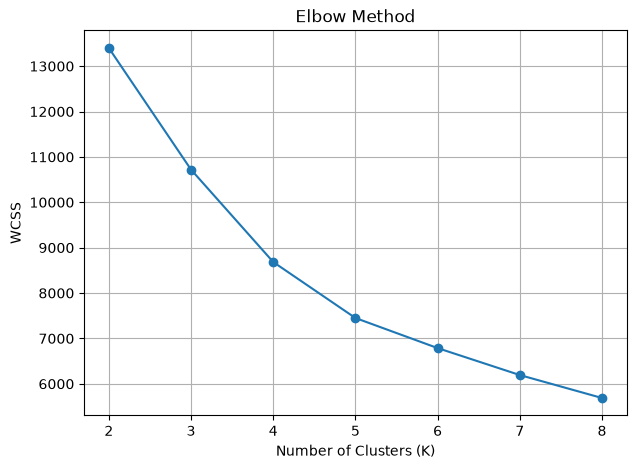

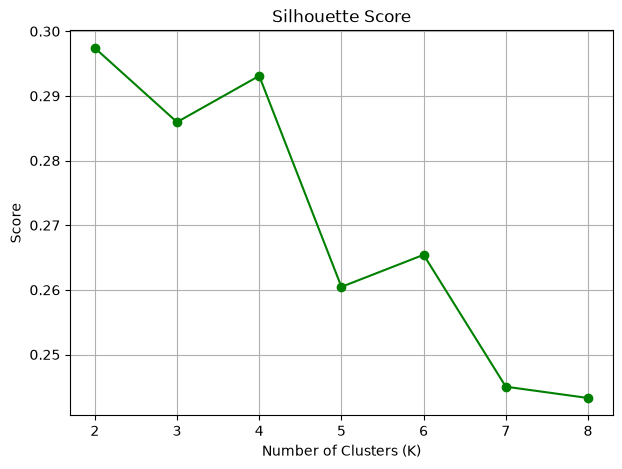

   K          WCSS  Silhouette Score
0  2  13399.461102          0.297410
1  3  10719.699154          0.285947
2  4   8683.651712          0.293099
3  5   7449.992617          0.260461
4  6   6786.892861          0.265422
5  7   6192.938214          0.245022
6  8   5687.219814          0.243273

Best K = 2

Cluster Centers
          spend  frequency    recency  avg_order_value
0  78621.982536   9.960499  30.518919      8136.548466
1  37887.065511   6.183044  58.886705      6277.689628


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv("uuser.csv")
X = df[["spend","frequency","recency","avg_order_value"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
k_values = range(2, 9)
wcss = []
silhouette_scores = []
for k in k_values:
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = model.fit_predict(X_scaled)
    wcss.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
plt.figure(figsize=(7,5))
plt.plot(k_values,wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()
plt.figure(figsize=(7,5))
plt.plot(k_values,silhouette_scores,marker="o",color="green")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.grid(True)
plt.show()
results = pd.DataFrame({ "K": list(k_values),"WCSS": wcss, "Silhouette Score": silhouette_scores})
print(results)
best_k = results.loc[results["Silhouette Score"].idxmax(),"K"]
print(f"\nBest K = {best_k}")
final_model = KMeans(n_clusters=int(best_k),random_state=42,n_init=10)
df["Cluster"] = final_model.fit_predict(X_scaled)
centers = pd.DataFrame(scaler.inverse_transform(final_model.cluster_centers_),columns=["spend","frequency","recency","avg_order_value" ])
print("\nCluster Centers")
print(centers)
df.to_csv(
    "users_clustered.csv",
    index=False
)

2. Profile each cluster: mean feature values + a one-line persona name ('Dormant big-spenders'). Which cluster
should Week 5's churn coupons target FIRST?

In [17]:
import numpy as np
cluster_profile = (df.groupby("Cluster")[["spend", "frequency", "recency", "avg_order_value"]].mean().round(2))
cluster_profile["Customers"] = df["Cluster"].value_counts().sort_index()
overall = df[["spend", "frequency", "recency", "avg_order_value"]].mean()
persona_names = {}
for cluster in cluster_profile.index:
    spend = cluster_profile.loc[cluster, "spend"]
    frequency = cluster_profile.loc[cluster, "frequency"]
    recency = cluster_profile.loc[cluster, "recency"]
    if spend > overall["spend"] and frequency > overall["frequency"] and recency < overall["recency"]:
        persona = "Loyal High-Value Customers"
    elif spend > overall["spend"] and recency > overall["recency"]:
        persona = "Dormant Big-Spenders"
    elif spend < overall["spend"] and frequency > overall["frequency"]:
        persona = "Frequent Budget Shoppers"
    elif frequency < overall["frequency"] and recency > overall["recency"]:
        persona = "At-Risk Customers"
    else:
        persona = "Regular Customers"
    persona_names[cluster] = persona
cluster_profile["Persona"] = cluster_profile.index.map(persona_names)
df["Persona"] = df["Cluster"].map(persona_names)
target_cluster = (
    cluster_profile[
        cluster_profile["Persona"] == "Dormant Big-Spenders"
    ]
)
print("cluster profile")
print(cluster_profile)
print("\n")
if len(target_cluster) > 0:
    print("target:")
    print(target_cluster[["Persona"]])
else:
    print("No cluster matched 'Dormant Big-Spenders'.")
    print("Target the cluster with high recency and high spend.")
df.to_csv("users_clustered_profiled.csv", index=False)

cluster profile
            spend  frequency  recency  avg_order_value  Customers  \
Cluster                                                             
0        78652.48       9.96    30.53          8135.86       2402   
1        37905.91       6.18    58.84          6280.47       2598   

                            Persona  
Cluster                              
0        Loyal High-Value Customers  
1                 At-Risk Customers  


No cluster matched 'Dormant Big-Spenders'.
Target the cluster with high recency and high spend.


3. Run PCA to 2 components; scatter-plot users colored by cluster. What % of variance do 2 PCs keep?

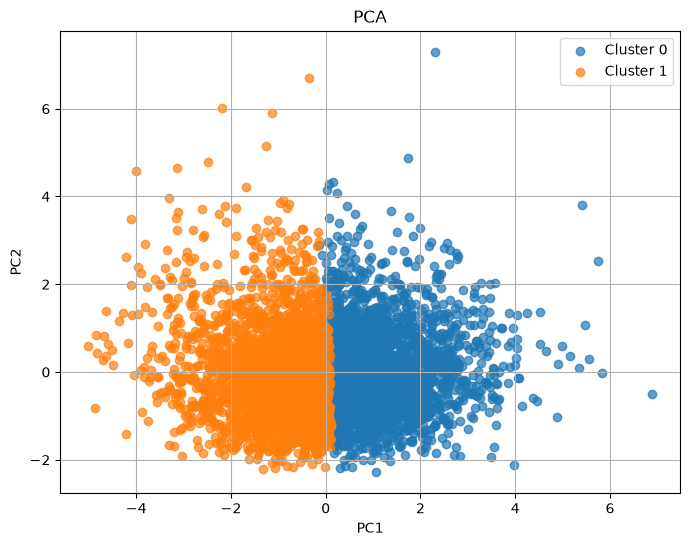

Explained Variance by PC1 : 53.31%
Explained Variance by PC2 : 27.76%
Total Variance Retained   : 81.07%


In [5]:
from sklearn.decomposition import PCA
features = ["spend","frequency", "recency","avg_order_value"]
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame({"PC1": X_pca[:, 0],"PC2": X_pca[:, 1],"Cluster": df["Cluster"]})
plt.figure(figsize=(8,6))
for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(subset["PC1"],subset["PC2"],label=f"Cluster {cluster}", alpha=0.7)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()
explained_variance = pca.explained_variance_ratio_
total_variance = explained_variance.sum() * 100
print("Explained Variance by PC1 : {:.2f}%".format(explained_variance[0] * 100))
print("Explained Variance by PC2 : {:.2f}%".format(explained_variance[1] * 100))
print("Total Variance Retained   : {:.2f}%".format(total_variance))

4. Run IsolationForest on order features; inspect the top-20 anomalies. Data errors, fraud candidates, or
corporate bulk orders? Decide their fate (Week 2 outlier classes).

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import IsolationForest
df = pd.read_csv("features.csv")
features = ["weight_kg","distance_km","quantity","price","shipping_cost","price_per_item","weight_per_item","shipping_per_km","shipping_price_ratio"]
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
iso = IsolationForest(contamination=0.02, random_state=42)
df["Anomaly"] = iso.fit_predict(X_scaled)
df["Score"] = iso.decision_function(X_scaled)
top20 = (df[df["Anomaly"] == -1].sort_values("Score").head(20))
def classify(row):
    if row["quantity"] >= 20 or row["price"] >= 1000:
        return "Corporate Bulk Order"
    elif (row ["shipping_cost"] < 0 or row["price"] < 0 or row["weight_kg"] <= 0):
        return "Data Error"
    elif row["shipping_price_ratio"] > 0.6:
        return "Fraud Candidate"
    else:
        return "Needs Manual Review"
top20["Outlier_Class"] = top20.apply(classify, axis=1)
print("anomalies")
print(top20[["order_id","user_id","price","quantity","shipping_cost","shipping_price_ratio","Score","Outlier_Class"]])
print("\n")
print("summary")
print(top20["Outlier_Class"].value_counts())
top20.to_csv("anomalies.csv", index=False)

anomalies
       order_id  user_id    price  quantity  shipping_cost  \
21736     21736      412   1098.0         1          442.0   
8484       8484     1962    203.0         1          326.0   
37686     37686     4001    490.0         1          303.0   
23904     23904     3068    848.0         1          115.0   
16563     16563     2405    760.0         1          333.0   
7233       7233     2593   7094.0         1          354.0   
17874     17874     3420    739.0         1          295.0   
788         788     3358    981.0         3          346.0   
23590     23590     3687   1374.0         1          402.0   
16723     16723     3003  11649.0         1          241.0   
22671     22671     2927    700.0         1          301.0   
30260     30260     4806    347.0         1          197.0   
152         152     4426   1575.0         1          122.0   
13317     13317     1642   2234.0         1          383.0   
36513     36513     2455   1127.0         1           62.0  